# NB0 — EDA & Data Preparation
### FruitSeg30 — Semantic Segmentation Benchmark

This notebook covers:
- **Task A** — Exploratory Data Analysis (pixel-level class distribution, image geometry, representative samples, integrity checks)
- **Task B** — Leakage-safe Train / Validation / Test split (70/15/15), materialized as **physical `train/`, `val/`, `test/` folders** (each with `images/` and `masks/`)
- **Task C** — Data augmentation pipeline (Albumentations, train split only)
- **Task D** — Sanity-check visualization of post-augmentation training samples

**Input:** the output of our pre-processing notebook (`fruitseg30-preprocess.ipynb`), which already
flattened the raw `FruitSeg30/<ClassName>/Images|Mask` structure into:

```
FruitSeg30_processed/
├── images/            Apple_Gala_0001.png ...
├── masks/              (colorized, same filename)
└── class_dict.csv      name,r,g,b  (Background + 30 fruit classes)
```

**Output of this notebook** (what NB1–NB3 will actually consume):

```
FruitSeg30_processed/
├── train/
│   ├── images/         Apple_Gala_0001.png ...
│   └── masks/          (same filenames)
├── val/
│   ├── images/
│   └── masks/
├── test/
│   ├── images/
│   └── masks/
├── class_dict.csv
└── class_weights.csv   (inverse pixel-frequency weights for the Task E loss)
```



In [1]:
# ── Cell: Imports ─────────────────────────────────────────────────────────
import os, re, csv, hashlib, random, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Imports OK')


Imports OK


In [2]:
# ── Cell: Locate the processed dataset (robust to subfolder / path variation) ──

CANDIDATE_ROOTS = [
    Path('/kaggle/input/datasets/mohuaakter/fruitseg30-dataset/FruitSeg30_processed'),
    Path('/kaggle/input/fruitseg30-processed/FruitSeg30_processed'),
    Path('/kaggle/input/fruitseg30-preprocess/FruitSeg30_processed'),
    Path('/kaggle/working/FruitSeg30_processed'),
]

def looks_like_processed_root(p: Path) -> bool:
    return (p / 'images').is_dir() and (p / 'masks').is_dir() and (p / 'class_dict.csv').is_file()

def find_processed_root():
    for p in CANDIDATE_ROOTS:
        if looks_like_processed_root(p):
            return p
    # Fallback: search anywhere under /kaggle/input or cwd for class_dict.csv
    search_bases = [Path('/kaggle/input'), Path('.')]
    for base in search_bases:
        if not base.exists():
            continue
        for hit in base.rglob('class_dict.csv'):
            root = hit.parent
            if looks_like_processed_root(root):
                return root
    raise FileNotFoundError(
        "Could not find FruitSeg30_processed/{images,masks,class_dict.csv}. "
        "Attach the preprocessing notebook's output as a data source, or edit CANDIDATE_ROOTS."
    )

ROOT = find_processed_root()
IMAGES_DIR = ROOT / 'images'
MASKS_DIR  = ROOT / 'masks'
print('Processed dataset root:', ROOT)
print('images/:', len(list(IMAGES_DIR.glob('*.png'))), 'files')
print('masks/ :', len(list(MASKS_DIR.glob('*.png'))), 'files')


Processed dataset root: /kaggle/input/datasets/mohuaakter/fruitseg30-dataset/FruitSeg30_processed
images/: 1969 files
masks/ : 1969 files


In [3]:
# ── Cell: Load class dictionary + recover per-file class labels ─────────────
# Filenames are '<SanitizedClassName>_<4-digit-index>.png' (e.g. 'Mango_Alphonso_0007.png').
# We strip the trailing '_<digits>' to recover the sanitized class name, then map it
# back to the *original* (space-containing) class name via class_dict.csv.
# This is robust to underscores that are already part of a class name
# (e.g. 'Apple_Gala', 'Mango_Alphonso') because we only strip the LAST '_####' group.

class_df = pd.read_csv(ROOT / 'class_dict.csv')
assert len(class_df) == 31, f'Expected 31 rows (Background + 30 classes), got {len(class_df)}'

FRUIT_CLASSES = class_df[class_df['name'] != 'Background']['name'].tolist()
assert len(FRUIT_CLASSES) == 30, f'Expected 30 fruit classes, got {len(FRUIT_CLASSES)}'

NAME_TO_IDX = {row['name']: i for i, row in class_df.reset_index(drop=True).iterrows()}  # Background=0
IDX_TO_COLOR = {i: (row.r, row.g, row.b) for i, row in class_df.reset_index(drop=True).iterrows()}
SANITIZED_TO_ORIGINAL = {name.replace(' ', '_'): name for name in FRUIT_CLASSES}

STEM_RE = re.compile(r'^(.*)_(\d{4})$')

def class_from_filename(stem: str) -> str:
    m = STEM_RE.match(stem)
    if not m:
        raise ValueError(f'Unexpected filename pattern: {stem}')
    sanitized = m.group(1)
    if sanitized not in SANITIZED_TO_ORIGINAL:
        raise KeyError(f'Unknown class prefix "{sanitized}" from stem "{stem}"')
    return SANITIZED_TO_ORIGINAL[sanitized]

# Build the master file index
records = []
for img_path in sorted(IMAGES_DIR.glob('*.png')):
    mask_path = MASKS_DIR / img_path.name
    cls = class_from_filename(img_path.stem)
    records.append({'stem': img_path.stem, 'class_name': cls,
                     'image_path': str(img_path), 'mask_path': str(mask_path),
                     'mask_exists': mask_path.is_file()})

file_df = pd.DataFrame(records)
print(f'Indexed {len(file_df)} image files across {file_df.class_name.nunique()} classes')

missing_classes = set(FRUIT_CLASSES) - set(file_df.class_name.unique())
print('Classes missing entirely:', missing_classes if missing_classes else 'none ✓')
print('Images missing a mask file:', int((~file_df.mask_exists).sum()))

print('\nPer-class image counts (Task A precursor):')
print(file_df.class_name.value_counts().sort_index())


Indexed 1969 image files across 30 classes
Classes missing entirely: none ✓
Images missing a mask file: 0

Per-class image counts (Task A precursor):
class_name
Apple_Gala                 65
Apple_Golden Delicious     57
Avocado                    72
Banana                     82
Berry                      62
Burmese Grape              78
Carambola                 100
Date Palm                 147
Dragon                     96
Elephant Apple             81
Grape                      82
Green Coconut              37
Guava                      55
Hog Plum                   91
Kiwi                       61
Lichi                      48
Malta                      50
Mango Golden Queen         16
Mango_Alphonso             45
Mango_Amrapali             67
Mango_Bari                 57
Mango_Himsagar             85
Olive                      51
Orange                     83
Palm                       59
Persimmon                  33
Pineapple                  65
Pomegranate                61

## Task A — Exploratory Data Analysis

Order: 
*  integrity checks — corrupted files, mismatched image/mask sizes, near-duplicates —
**before** trusting any statistics computed from the data; 
*  pixel-level class distribution;
*  image size / aspect-ratio distribution; 
*  representative image–mask pairs per class;
*  written summary of class imbalance and its consequence for the Task E loss function.


In [4]:
# ── Task A.1: Corrupted-file and image/mask size-mismatch check ─────────────
corrupted = []
size_mismatch = []

for row in tqdm(file_df.itertuples(), total=len(file_df), desc='Integrity check'):
    if not row.mask_exists:
        corrupted.append((row.stem, 'mask file missing'))
        continue
    try:
        with Image.open(row.image_path) as im:
            im_size = im.size
            im.verify()
    except Exception as e:
        corrupted.append((row.stem, f'image unreadable: {e}'))
        continue
    try:
        with Image.open(row.mask_path) as mk:
            mk_size = mk.size
    except Exception as e:
        corrupted.append((row.stem, f'mask unreadable: {e}'))
        continue
    # PIL Image.verify() closes the file handle; re-open to safely read size again if needed
    if im_size != mk_size:
        size_mismatch.append((row.stem, im_size, mk_size))

print(f'Corrupted / unreadable files : {len(corrupted)}')
for s in corrupted[:10]:
    print('  ', s)
print(f'\nImage/mask size mismatches   : {len(size_mismatch)}')
for s in size_mismatch[:10]:
    print('  ', s)
if not corrupted and not size_mismatch:
    print('\n✓ No corrupted files and no image/mask size mismatches detected.')


Integrity check:   0%|          | 0/1969 [00:00<?, ?it/s]

Corrupted / unreadable files : 0

Image/mask size mismatches   : 52
   ('Guava_0001', (4000, 3000), (3000, 4000))
   ('Guava_0002', (4000, 3000), (3000, 4000))
   ('Guava_0003', (4000, 3000), (3000, 4000))
   ('Guava_0004', (4000, 3000), (3000, 4000))
   ('Guava_0005', (4000, 3000), (3000, 4000))
   ('Guava_0006', (4000, 3000), (3000, 4000))
   ('Guava_0007', (4000, 3000), (3000, 4000))
   ('Guava_0008', (4000, 3000), (3000, 4000))
   ('Guava_0009', (4000, 3000), (3000, 4000))
   ('Guava_0010', (4000, 3000), (3000, 4000))


In [5]:
# ── Task A.2: Near-duplicate detection ───────────────────────────────────────
# Cheap, dependency-free perceptual hash: downsample to 8x8 grayscale, threshold
# against the row/column mean (a compact average-hash). Images whose hash strings
# are identical (or Hamming distance <= 2) are flagged as near-duplicates.
# This matters for Task B: duplicate groups must not be split across train/val/test
# (that would leak near-identical content between splits).

def average_hash(path, hash_size=8):
    with Image.open(path) as im:
        im = im.convert('L').resize((hash_size, hash_size), Image.LANCZOS)
        arr = np.asarray(im, dtype=np.float32)
    avg = arr.mean()
    bits = (arr > avg).flatten()
    return ''.join('1' if b else '0' for b in bits)

def hamming(a, b):
    return sum(c1 != c2 for c1, c2 in zip(a, b))

hashes = {}
for row in tqdm(file_df.itertuples(), total=len(file_df), desc='Hashing images'):
    try:
        hashes[row.stem] = average_hash(row.image_path)
    except Exception:
        hashes[row.stem] = None

# Group exact hash collisions first (fast), only within the same class (duplicates
# are only a splitting concern within a class since splits are stratified per class)
by_class = defaultdict(list)
for row in file_df.itertuples():
    by_class[row.class_name].append(row.stem)

dup_groups = []  # list of sets of stems that are near-duplicates of each other
seen = set()
for cls, stems in by_class.items():
    hash_to_stems = defaultdict(list)
    for s in stems:
        h = hashes.get(s)
        if h is not None:
            hash_to_stems[h].append(s)
    for h, group in hash_to_stems.items():
        if len(group) > 1:
            dup_groups.append(set(group))
            seen.update(group)

n_dup_images = sum(len(g) for g in dup_groups)
print(f'Exact-hash duplicate groups found: {len(dup_groups)}  (covering {n_dup_images} images)')
for g in dup_groups[:5]:
    print('  ', sorted(g))

# stem -> duplicate-group id, used later to keep each group inside a single split
STEM_TO_DUPGROUP = {}
for gid, g in enumerate(dup_groups):
    for s in g:
        STEM_TO_DUPGROUP[s] = gid
print(f'\n{len(STEM_TO_DUPGROUP)} of {len(file_df)} images belong to a duplicate group.')


Hashing images:   0%|          | 0/1969 [00:00<?, ?it/s]

Exact-hash duplicate groups found: 62  (covering 162 images)
   ['Avocado_0003', 'Avocado_0033']
   ['Avocado_0005', 'Avocado_0010', 'Avocado_0012', 'Avocado_0014', 'Avocado_0015', 'Avocado_0016', 'Avocado_0035']
   ['Avocado_0011', 'Avocado_0013', 'Avocado_0017', 'Avocado_0020', 'Avocado_0029', 'Avocado_0030', 'Avocado_0031', 'Avocado_0036', 'Avocado_0039', 'Avocado_0044', 'Avocado_0045', 'Avocado_0046', 'Avocado_0059', 'Avocado_0062']
   ['Avocado_0019', 'Avocado_0037']
   ['Avocado_0021', 'Avocado_0022']

162 of 1969 images belong to a duplicate group.


Counting pixels:   0%|          | 0/1969 [00:00<?, ?it/s]

            class_name  pixel_count  pixel_pct
            Background    683938603  58.984844
                 Guava    302819236  26.116007
                Dragon     13036760   1.124328
             Carambola     10190980   0.878900
        Mango_Himsagar      9865979   0.850871
        Elephant Apple      9662731   0.833342
             Date Palm      8306419   0.716370
              Hog Plum      8157906   0.703561
        Mango_Amrapali      8062261   0.695313
             Pineapple      8013048   0.691068
            Watermelon      7728705   0.666546
            Mango_Bari      7598682   0.655332
           Pomegranate      7244606   0.624796
         Green Coconut      6810506   0.587358
                Orange      6709033   0.578606
                Banana      6565522   0.566230
         Burmese Grape      5303975   0.457430
            White Pear      5016828   0.432666
                 Malta      5012602   0.432301
            Apple_Gala      4895407   0.422194
        Mango

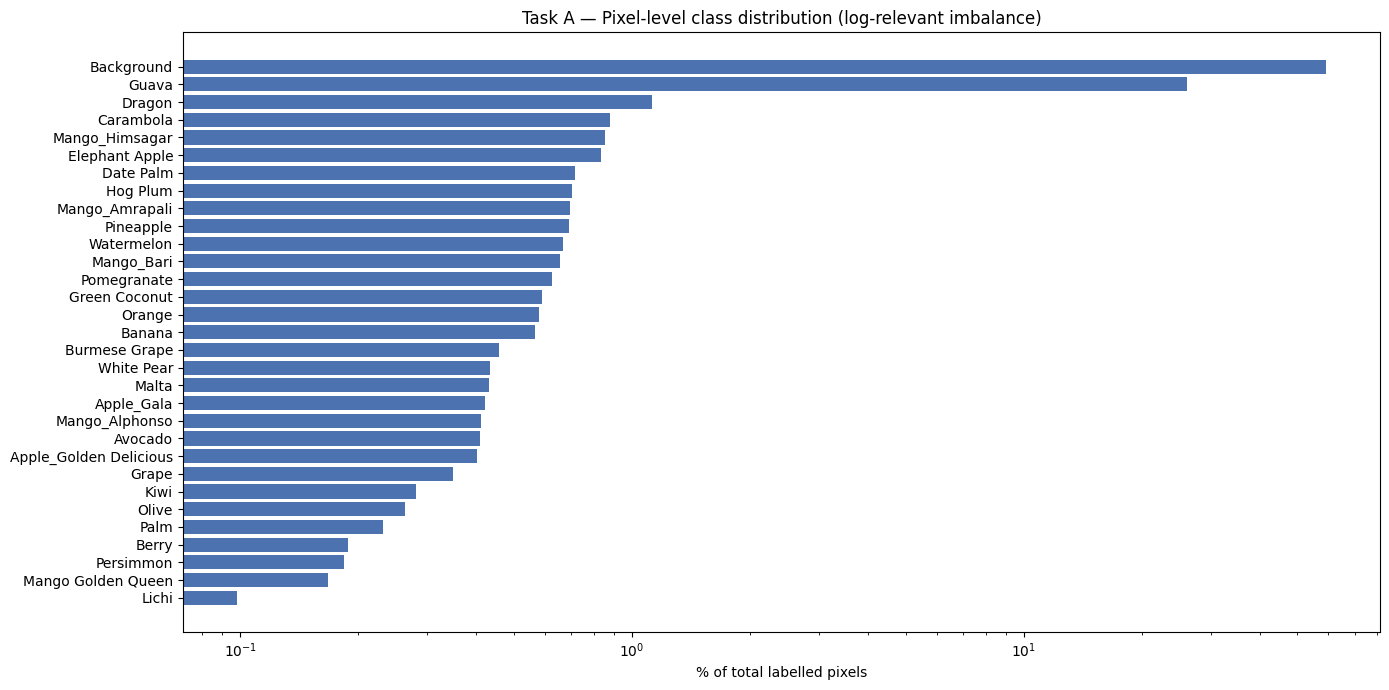


Max/min pixel-count ratio across fruit classes: 600.9x


In [6]:
# ── Task A.3: Pixel-level class distribution ─────────────────────────────────
# Colours in class_dict.csv are exact (they were painted by our preprocessing step),
# so a mask pixel's class = whichever palette colour it matches exactly; unmatched
# pixels (anti-aliased edges, if any) fall back to nearest-colour lookup.

PALETTE = np.array([IDX_TO_COLOR[i] for i in range(len(class_df))], dtype=np.int32)  # (31, 3)

def mask_to_class_counts(mask_path):
    rgb = np.asarray(Image.open(mask_path).convert('RGB'), dtype=np.int32)
    flat = rgb.reshape(-1, 3)
    # Exact match against palette; unmatched pixels -> nearest colour (robust to png dithering)
    counts = np.zeros(len(PALETTE), dtype=np.int64)
    # Vectorized exact match
    matched = np.zeros(len(flat), dtype=bool)
    for idx, color in enumerate(PALETTE):
        eq = np.all(flat == color, axis=1)
        counts[idx] += eq.sum()
        matched |= eq
    if not matched.all():
        unmatched = flat[~matched]
        dists = ((unmatched[:, None, :] - PALETTE[None, :, :]) ** 2).sum(axis=2)
        nearest = dists.argmin(axis=1)
        for idx in nearest:
            counts[idx] += 1
    return counts

PIXEL_COUNTS_PATH = Path('/kaggle/working/pixel_class_counts.npy')
if PIXEL_COUNTS_PATH.exists():
    total_pixel_counts = np.load(PIXEL_COUNTS_PATH)
else:
    total_pixel_counts = np.zeros(len(class_df), dtype=np.int64)
    for row in tqdm(file_df.itertuples(), total=len(file_df), desc='Counting pixels'):
        total_pixel_counts += mask_to_class_counts(row.mask_path)
    np.save(PIXEL_COUNTS_PATH, total_pixel_counts)

pixel_dist_df = pd.DataFrame({
    'class_name': class_df['name'],
    'pixel_count': total_pixel_counts,
    'pixel_pct': 100 * total_pixel_counts / total_pixel_counts.sum(),
}).sort_values('pixel_count', ascending=False).reset_index(drop=True)

print(pixel_dist_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 7))
order = pixel_dist_df.sort_values('pixel_count')
ax.barh(order['class_name'], order['pixel_pct'], color='#4c72b0')
ax.set_xlabel('% of total labelled pixels')
ax.set_title('Task A — Pixel-level class distribution (log-relevant imbalance)')
ax.set_xscale('log')
plt.tight_layout(); plt.show()

imbalance_ratio = pixel_dist_df['pixel_count'].max() / pixel_dist_df[pixel_dist_df.class_name != 'Background']['pixel_count'].min()
print(f'\nMax/min pixel-count ratio across fruit classes: {imbalance_ratio:,.1f}x')


Reading image sizes:   0%|          | 0/1969 [00:00<?, ?it/s]

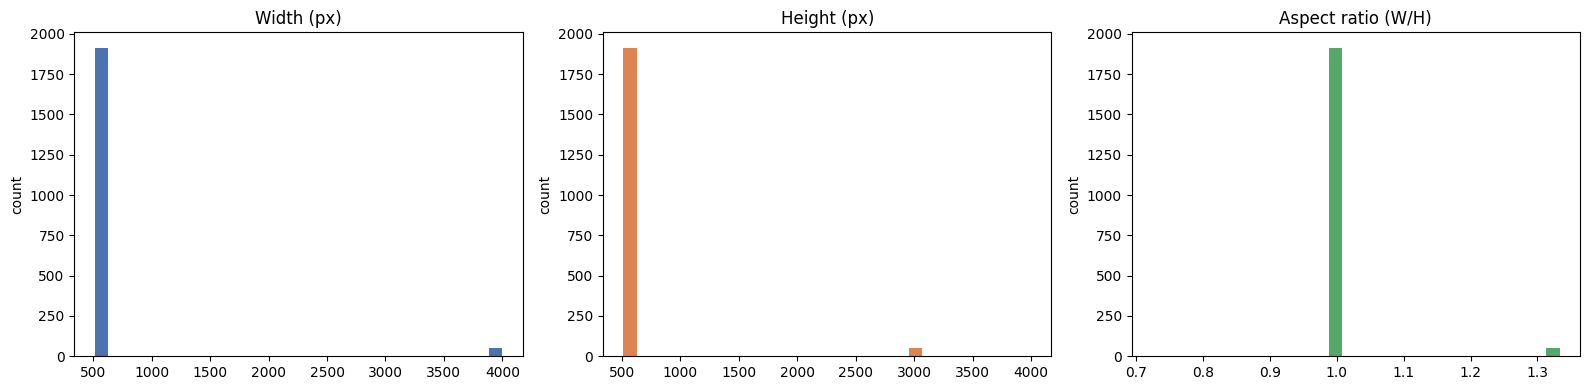

             width       height  aspect_ratio
count  1969.000000  1969.000000   1969.000000
mean    607.744033   582.855256      1.008413
std     566.513494   419.482346      0.054459
min     512.000000   512.000000      0.723464
25%     512.000000   512.000000      1.000000
50%     512.000000   512.000000      1.000000
75%     512.000000   512.000000      1.000000
max    4000.000000  4000.000000      1.333333

Unique (width,height) pairs: 5


In [7]:
# ── Task A.4: Image size and aspect-ratio distribution ───────────────────────
sizes = []
for row in tqdm(file_df.itertuples(), total=len(file_df), desc='Reading image sizes'):
    with Image.open(row.image_path) as im:
        sizes.append(im.size)  # (W, H)

size_df = pd.DataFrame(sizes, columns=['width', 'height'])
size_df['aspect_ratio'] = size_df['width'] / size_df['height']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(size_df['width'], bins=30, color='#4c72b0'); axes[0].set_title('Width (px)')
axes[1].hist(size_df['height'], bins=30, color='#dd8452'); axes[1].set_title('Height (px)')
axes[2].hist(size_df['aspect_ratio'], bins=30, color='#55a868'); axes[2].set_title('Aspect ratio (W/H)')
for ax in axes: ax.set_ylabel('count')
plt.tight_layout(); plt.show()

print(size_df.describe())
print(f"\nUnique (width,height) pairs: {size_df[['width','height']].drop_duplicates().shape[0]}")


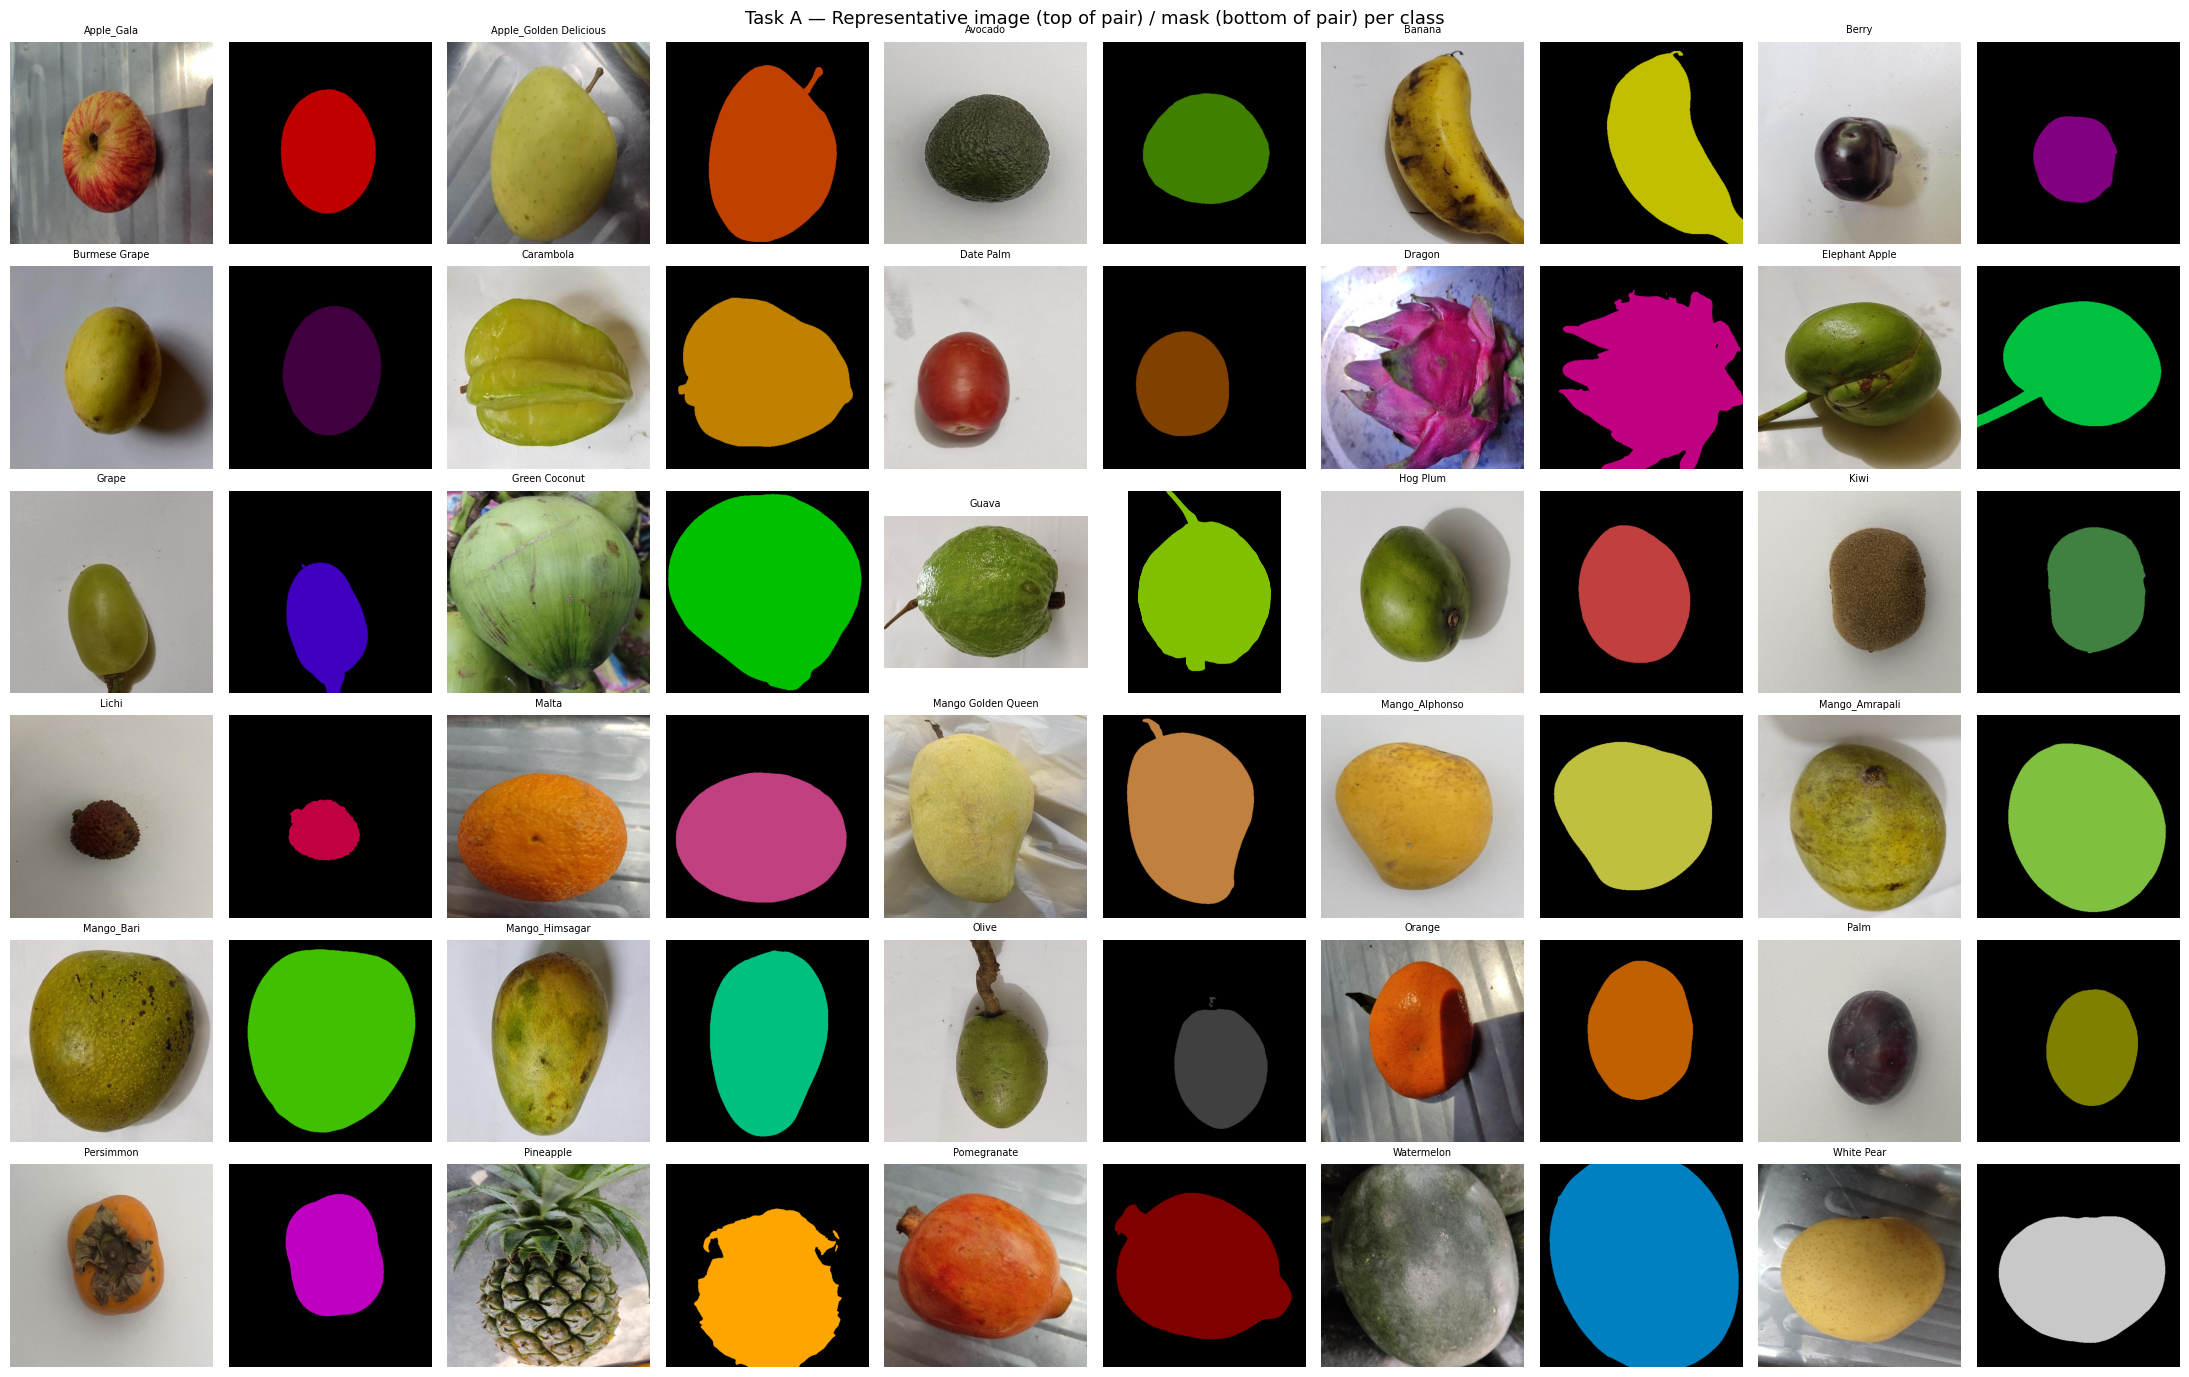

In [8]:
# ── Task A.5: Representative image-mask pair for every class ────────────────
fig, axes = plt.subplots(6, 10, figsize=(22, 14))
axes = axes.flatten()
for i, cls in enumerate(sorted(FRUIT_CLASSES)):
    sample = file_df[file_df.class_name == cls].sample(1, random_state=SEED).iloc[0]
    img = Image.open(sample.image_path)
    mask = Image.open(sample.mask_path)
    axes[2*i].imshow(img);  axes[2*i].axis('off');  axes[2*i].set_title(cls, fontsize=7)
    axes[2*i+1].imshow(mask); axes[2*i+1].axis('off')
for ax in axes[2*len(FRUIT_CLASSES):]:
    ax.axis('off')
plt.suptitle('Task A — Representative image (top of pair) / mask (bottom of pair) per class', fontsize=13)
plt.tight_layout(); plt.show()


## Task B — Leakage-Safe Data Splitting

**Split ratio:** 70 / 15 / 15 (train / val / test) — used as-is, no deviation needed since
every one of the 30 classes has enough samples for a stratified split at this ratio (verified
below).

**Leakage safety:**
- Splitting is **stratified per class** so every split contains all 30 fruit classes in
  proportion — required since we have 30 classes and want each split representative.
- Any **duplicate group** found in Task A.2 is assigned to a *single* split — a duplicate
  pair straddling train/test would let the model "cheat" (validate/test on something it
  effectively already saw during training), which is exactly the leakage this task is
  designed to prevent.
- Splitting is done **once here** and saved as CSV artifacts; every downstream notebook
  loads these files rather than re-splitting, guaranteeing identical splits everywhere.


In [9]:
# ── Task B: Build leakage-safe, stratified 70/15/15 split ────────────────────
from sklearn.model_selection import train_test_split

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9

file_df['dup_group'] = file_df['stem'].map(STEM_TO_DUPGROUP)
# Give every image without a duplicate its own unique group id so it is treated as a
# singleton "group" -> group-aware splitting collapses to ordinary stratified splitting
# for the (majority) non-duplicated images, and keeps true duplicates together.
next_gid = (max(STEM_TO_DUPGROUP.values()) + 1) if STEM_TO_DUPGROUP else 0
singleton_ids = iter(range(next_gid, next_gid + len(file_df)))
file_df['dup_group'] = file_df.apply(
    lambda r: r['dup_group'] if pd.notna(r['dup_group']) else next(singleton_ids), axis=1
).astype(int)

# One representative row per group, carrying the group's class (duplicates are always
# within the same class in this dataset, since hashing was scoped per-class above).
group_reps = file_df.drop_duplicates('dup_group')[['dup_group', 'class_name']]

def stratified_group_split(reps, frac_train, frac_val, frac_test, seed=SEED):
    train_ids, val_ids, test_ids = [], [], []
    for cls, sub in reps.groupby('class_name'):
        gids = sub['dup_group'].tolist()
        tr, rest = train_test_split(gids, train_size=frac_train, random_state=seed)
        val_size_rel = frac_val / (frac_val + frac_test)
        va, te = train_test_split(rest, train_size=val_size_rel, random_state=seed)
        train_ids += tr; val_ids += va; test_ids += te
    return set(train_ids), set(val_ids), set(test_ids)

train_gids, val_gids, test_gids = stratified_group_split(group_reps, TRAIN_FRAC, VAL_FRAC, TEST_FRAC)

def assign_split(gid):
    if gid in train_gids: return 'train'
    if gid in val_gids: return 'val'
    return 'test'

file_df['split'] = file_df['dup_group'].apply(assign_split)

print(file_df['split'].value_counts())
print('\nPer-class per-split counts (every class must appear in every split):')
pivot = file_df.pivot_table(index='class_name', columns='split', values='stem', aggfunc='count', fill_value=0)
pivot = pivot[['train', 'val', 'test']]
print(pivot.to_string())

missing_in_split = pivot[(pivot == 0).any(axis=1)]
if len(missing_in_split):
    print('\n✗ WARNING — classes missing from at least one split:')
    print(missing_in_split)
else:
    print('\n✓ All 30 classes present in train, val, AND test splits.')


split
train    1369
test      309
val       291
Name: count, dtype: int64

Per-class per-split counts (every class must appear in every split):
split                   train  val  test
class_name                              
Apple_Gala                 45   10    10
Apple_Golden Delicious     39    9     9
Avocado                    50   12    10
Banana                     57   12    13
Berry                      44    8    10
Burmese Grape              54   12    12
Carambola                  70   15    15
Date Palm                 102   22    23
Dragon                     67   14    15
Elephant Apple             56   12    13
Grape                      56   12    14
Green Coconut              25    6     6
Guava                      38    9     8
Hog Plum                   63   14    14
Kiwi                       46    6     9
Lichi                      33    8     7
Malta                      35    7     8
Mango Golden Queen         11    2     3
Mango_Alphonso             32    6  

In [10]:
# ── Task B: Materialize the physical split — the shared artifact for NB1–NB3 ─


import shutil

OUT_ROOT = Path('/kaggle/working/FruitSeg30_processed')
for split_name in ['train', 'val', 'test']:
    (OUT_ROOT / split_name / 'images').mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / split_name / 'masks').mkdir(parents=True, exist_ok=True)

for row in tqdm(file_df.itertuples(), total=len(file_df), desc='Copying into split folders'):
    img_dst = OUT_ROOT / row.split / 'images' / f'{row.stem}.png'
    msk_dst = OUT_ROOT / row.split / 'masks' / f'{row.stem}.png'
    if not img_dst.exists():
        shutil.copyfile(row.image_path, img_dst)
    if not msk_dst.exists():
        shutil.copyfile(row.mask_path, msk_dst)

class_df.to_csv(OUT_ROOT / 'class_dict.csv', index=False)

# Save class weights (inverse-frequency, normalized) for the Task E weighted loss.
freq = total_pixel_counts / total_pixel_counts.sum()
inv_freq = 1.0 / np.clip(freq, 1e-12, None)
class_weights = inv_freq / inv_freq.sum() * len(inv_freq)   # normalize so mean weight ~= 1
weights_df = pd.DataFrame({'class_name': class_df['name'], 'class_idx': range(len(class_df)),
                            'pixel_count': total_pixel_counts, 'class_weight': class_weights})
weights_df.to_csv(OUT_ROOT / 'class_weights.csv', index=False)

print('Split materialized at', OUT_ROOT)
for split_name in ['train', 'val', 'test']:
    n_img = len(list((OUT_ROOT / split_name / 'images').glob('*.png')))
    n_msk = len(list((OUT_ROOT / split_name / 'masks').glob('*.png')))
    print(f'  {split_name}: {n_img} images, {n_msk} masks')
print('\nclass_weights.csv preview:')
print(weights_df.to_string(index=False))
print("\nSave this notebook's output as a Kaggle Dataset (e.g. 'fruitseg30-processed-split'). "
      "NB1-NB3 will add that dataset and read train/ val/ test/ directly.")


Copying into split folders:   0%|          | 0/1969 [00:00<?, ?it/s]

Split materialized at /kaggle/working/FruitSeg30_processed
  train: 1369 images, 1369 masks
  val: 291 images, 291 masks
  test: 309 images, 309 masks

class_weights.csv preview:
            class_name  class_idx  pixel_count  class_weight
            Background          0    683938603      0.006737
            Apple_Gala          1      4895407      0.941220
Apple_Golden Delicious          2      4653110      0.990231
               Avocado          3      4733833      0.973345
                Banana          4      6565522      0.701796
                 Berry          5      2180918      2.112713
         Burmese Grape          6      5303975      0.868717
             Carambola          7     10190980      0.452131
             Date Palm          8      8306419      0.554710
                Dragon          9     13036760      0.353436
        Elephant Apple         10      9662731      0.476848
                 Grape         11      4047294      1.138453
         Green Coconut      

## Task C — Data Augmentation (Albumentations, **train split only**)

Domain considerations for FruitSeg30:
- These are **close-up product-style photos of individual fruits** on a plain backdrop —
  there is no scene "up/down" gravity cue (unlike street scenes), so unlike the assignment's
  own street-view caution, **vertical flip is safe here** and adds useful viewpoint variety.
- **Colour is a discriminating feature between visually-similar classes**
  (e.g. `Apple_Gala` vs `Apple_Golden Delicious`, or the five `Mango_*` cultivars), so hue
  jitter is kept **mild** and low-probability rather than aggressive — we don't want the
  augmentation itself to erase the visual cue the model needs to learn.
- No perspective/scale distortion so extreme it destroys small structures (stems, calyx) that
  matter for boundary-accurate segmentation.
- All spatial transforms are applied identically to image **and** mask (`Compose(..., is_check_shapes=False)`
  with `mask` passed alongside `image`, per Albumentations' synchronized-transform contract).


In [11]:
# ── Task C: Albumentations pipeline ──────────────────────────────────────────
import albumentations as A

IMG_SIZE = 512

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),      # fruit photographed from either side is equally valid
    A.VerticalFlip(p=0.3),        # no gravity/orientation cue in a fruit close-up (justified above)
    A.RandomRotate90(p=0.3),      # fruits have no canonical "upright" pose
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=20,
                        border_mode=0, p=0.5),   # mild pose/distance jitter, small rotation only
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),  # lighting variation
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10, p=0.3),
        # kept mild & low-probability: hue is a discriminating cue between similar cultivars
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),   # mild camera-focus variability
    A.CoarseDropout(max_holes=4, max_height=IMG_SIZE // 12, max_width=IMG_SIZE // 12, p=0.2),
        # light occlusion robustness (leaves/hands partially covering fruit)
], additional_targets={'mask': 'mask'})

val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
], additional_targets={'mask': 'mask'})

print('Train pipeline steps:')
for t in train_transform.transforms:
    print(' -', t)
print('\nVal/Test pipeline: Resize only (no stochastic augmentation, per Task C requirement).')


Train pipeline steps:
 - Resize(p=1.0, area_for_downscale=None, height=512, interpolation=1, mask_interpolation=0, width=512)
 - HorizontalFlip(p=0.5)
 - VerticalFlip(p=0.3)
 - RandomRotate90(p=0.3)
 - ShiftScaleRotate(p=0.5, shift_limit_x=(-0.05, 0.05), shift_limit_y=(-0.05, 0.05), scale_limit=(-0.15000000000000002, 0.1499999999999999), rotate_limit=(-20.0, 20.0), interpolation=1, border_mode=0, fill=0.0, fill_mask=0.0, rotate_method='largest_box', mask_interpolation=0)
 - RandomBrightnessContrast(p=0.4, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False)
 - HueSaturationValue(p=0.3, hue_shift_limit=(-8.0, 8.0), sat_shift_limit=(-15.0, 15.0), val_shift_limit=(-10.0, 10.0))
 - GaussianBlur(p=0.15, blur_limit=(3, 5), sigma_limit=(0.5, 3.0))
 - CoarseDropout(p=0.2, fill=0.0, fill_mask=None, hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2), num_holes_range=(1, 2))

Val/Test pipeline: Resize only (no stochastic augmentation, p

| Transform | p | Justification |
|---|---|---|
| Resize(512,512) | 1.0 | Fixed input size required by all three model backbones |
| HorizontalFlip | 0.5 | Fruit orientation is arbitrary left/right — always valid |
| VerticalFlip | 0.3 | No gravity cue in a close-up product photo (unlike street scenes) — safe here |
| RandomRotate90 | 0.3 | No canonical "upright" pose for a fruit on a plain backdrop |
| ShiftScaleRotate | 0.5 | Mild camera-distance / framing / small-angle jitter |
| RandomBrightnessContrast | 0.4 | Studio/ambient lighting varies across capture sessions |
| HueSaturationValue | 0.3 (mild ranges) | Kept low so color, a real discriminator between similar cultivars, isn't destroyed |
| GaussianBlur | 0.15 | Mild focus variation |
| CoarseDropout | 0.2 | Robustness to partial occlusion (leaves, hands, other fruit) |


In [12]:
# ── Cell: Dataset wrapper used by NB1–NB3 (identical logic re-defined in each) ──
import torch
from torch.utils.data import Dataset

class FruitSegDataset(Dataset):
    # Loads (image, class-index mask) pairs from one of NB0's split CSVs and applies
    # the Albumentations pipeline above ('train_transform' for split='train', otherwise
    # 'val_test_transform'). Colorized RGB masks are converted to a single-channel
    # class-index mask using the exact-match-then-nearest-colour palette lookup, matching
    # the palette recorded in class_dict.csv.

    def __init__(self, split_dir, palette, transform):
        split_dir = Path(split_dir)
        self.image_dir = split_dir / 'images'
        self.mask_dir = split_dir / 'masks'
        self.stems = sorted(p.stem for p in self.image_dir.glob('*.png'))
        self.palette = np.asarray(palette, dtype=np.int32)  # (num_classes, 3), index 0 = Background
        self.transform = transform

    def __len__(self):
        return len(self.stems)

    def _rgb_mask_to_index(self, rgb: np.ndarray) -> np.ndarray:
        flat = rgb.reshape(-1, 3).astype(np.int32)
        idx = np.zeros(len(flat), dtype=np.int64)
        matched = np.zeros(len(flat), dtype=bool)
        for i, color in enumerate(self.palette):
            eq = np.all(flat == color, axis=1)
            idx[eq] = i
            matched |= eq
        if not matched.all():
            unmatched_pos = np.where(~matched)[0]
            dists = ((flat[unmatched_pos][:, None, :] - self.palette[None, :, :]) ** 2).sum(axis=2)
            idx[unmatched_pos] = dists.argmin(axis=1)
        return idx.reshape(rgb.shape[:2])

    def __getitem__(self, i):
        stem = self.stems[i]
        image = np.array(Image.open(self.image_dir / f'{stem}.png').convert('RGB'))
        mask_rgb = np.array(Image.open(self.mask_dir / f'{stem}.png').convert('RGB'))
        mask_idx = self._rgb_mask_to_index(mask_rgb)

        aug = self.transform(image=image, mask=mask_idx)
        image_t = torch.from_numpy(aug['image']).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(aug['mask']).long()
        return image_t, mask_t, stem

train_ds = FruitSegDataset(OUT_ROOT / 'train', PALETTE, train_transform)
val_ds   = FruitSegDataset(OUT_ROOT / 'val',   PALETTE, val_test_transform)
test_ds  = FruitSegDataset(OUT_ROOT / 'test',  PALETTE, val_test_transform)
print(f'train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')


train=1369  val=291  test=309


## Task D — Sanity-Check Visualization (post-augmentation, mask overlay)

Required **before any training cell** in NB1–NB3. Confirms:
1. image and mask stay spatially aligned through the augmentation pipeline,
2. the class-colour legend is consistent with `class_dict.csv`,
3. augmented masks are not destroyed/degenerate (foreground still present after crops/dropout).


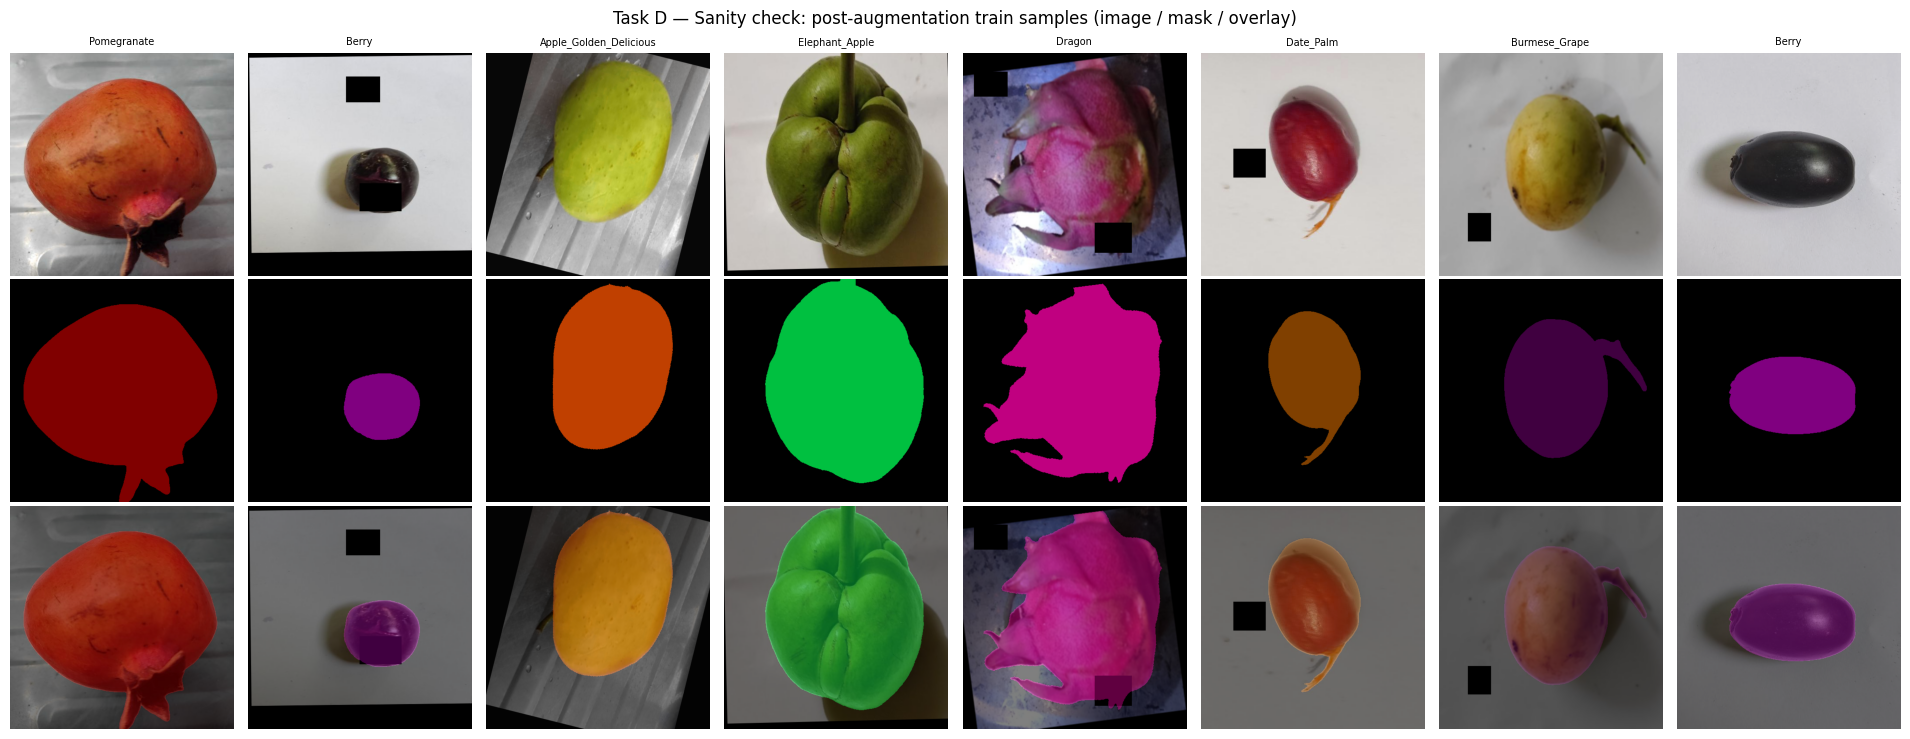

✓ If image/mask are spatially aligned above and no augmented mask is fully empty, the pipeline passes the Task D quality gate.
Fully-empty masks in a 200-sample probe: 0 (should be 0 or near-0)


In [13]:
# ── Task D: Grid of post-augmentation training samples with mask overlay ────
def overlay(image_chw, mask_hw, palette, alpha=0.5):
    img = (image_chw.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    color_mask = np.array(palette, dtype=np.uint8)[mask_hw.numpy()]
    blended = (img * (1 - alpha) + color_mask * alpha).astype(np.uint8)
    return img, color_mask, blended

n_show = 8
idxs = random.sample(range(len(train_ds)), n_show)
fig, axes = plt.subplots(3, n_show, figsize=(2.4 * n_show, 7.5))
for col, i in enumerate(idxs):
    img_t, mask_t, stem = train_ds[i]
    img, cmask, blend = overlay(img_t, mask_t, PALETTE)
    axes[0, col].imshow(img);   axes[0, col].axis('off')
    axes[1, col].imshow(cmask); axes[1, col].axis('off')
    axes[2, col].imshow(blend); axes[2, col].axis('off')
    axes[0, col].set_title(stem.rsplit('_', 1)[0], fontsize=7)
axes[0, 0].set_ylabel('Augmented image', fontsize=9)
axes[1, 0].set_ylabel('Mask', fontsize=9)
axes[2, 0].set_ylabel('Overlay', fontsize=9)
plt.suptitle('Task D — Sanity check: post-augmentation train samples (image / mask / overlay)', fontsize=12)
plt.tight_layout(); plt.show()

print('✓ If image/mask are spatially aligned above and no augmented mask is fully empty, '
      'the pipeline passes the Task D quality gate.')
# Explicit degenerate-mask check
empty_after_aug = sum(1 for i in range(min(200, len(train_ds))) if train_ds[i][1].sum() == 0)
print(f'Fully-empty masks in a 200-sample probe: {empty_after_aug} (should be 0 or near-0)')


## Handoff to NB1 / NB2 / NB3

This notebook's Kaggle output now contains:
```
/kaggle/working/FruitSeg30_processed/
├── train/images/ , train/masks/     (70%, all 30 classes, augmentation applied at load-time only)
├── val/images/   , val/masks/       (15%, all 30 classes, resize-only)
├── test/images/  , test/masks/      (15%, all 30 classes, resize-only, held out until Task F)
├── class_dict.csv                   (31 rows: Background + 30 fruit classes, RGB palette)
└── class_weights.csv                (inverse-pixel-frequency weights for the Task E weighted loss)
```
**Save this notebook's output as a Kaggle Dataset** (e.g. `fruitseg30-processed-split`), then add
that dataset to NB1 (`seg-deeplabv3`), NB2 (`seg-segformer-b0`), and NB3 (`seg-yolov26-semantic`) —
they all read `train/`, `val/`, `test/` directly (class is recovered from the filename prefix, no
CSV lookup needed) rather than re-deriving the split, which is what makes the Task H comparison valid.
